In [1]:
from pathlib import Path
import pandas as pd
import datetime as dt

In [2]:
INDIR = Path(r'Q:\Data\Observed\EmergingMobility\SFMTA_SharedMobilityDashboard')
TRIP_FILE = 'SharedMobilityTotalTripsTable_20251023.csv'
OUTDIR = Path(r'Q:\CMP\LOS Monitoring 2025\Micromobility')
OFILE = 'micromobility_trips_2017-2025.csv'

In [3]:
df = pd.read_csv(INDIR / TRIP_FILE)

In [4]:
df['trips'] = df['Number of Records'].map(lambda x: int(x.replace(',','')))

In [5]:
month_str_to_num = {
    'jan':1,
    'feb':2,
    'mar':3,
    'apr':4,
    'may':5,
    'jun':6,
    'jul':7,
    'aug':8,
    'sep':9,
    'oct':10,
    'nov':11,
    'dec':12}

In [6]:
df['month'] = df['Month of TRIP_START_DATE'].map(lambda x: month_str_to_num[x[:3].lower()])
df['year'] = df['Month of TRIP_START_DATE'].map(lambda x: int(x[-4:]))

In [7]:
df.sort_values(['year','month'], inplace=True)
df = df.loc[~(df['year'].eq(2025) & df['month'].eq(10))]

In [8]:
trips = pd.merge(
    (
    df.groupby(['year','month'], as_index=False)
    .agg({'trips':'sum'})
    .groupby(['year'])
    .agg({'trips':['sum','mean']})
    .rename(columns={'sum':'total_annual_trips','mean':'average_monthly_trips'})
    ),
    (
    df.loc[df['month'].isin([4,5])].groupby(['year','month'], as_index=False)
    .agg({'trips':'sum'})
    .groupby(['year'])
    .agg({'trips':['sum','mean']})
    .rename(columns={'sum':'total_aprmay_trips','mean':'average_aprmay_trips'})
    ),
    left_index=True, right_index=True, how='left'
)

In [9]:
trips.columns = trips.columns.droplevel(0)

<Axes: xlabel='year'>

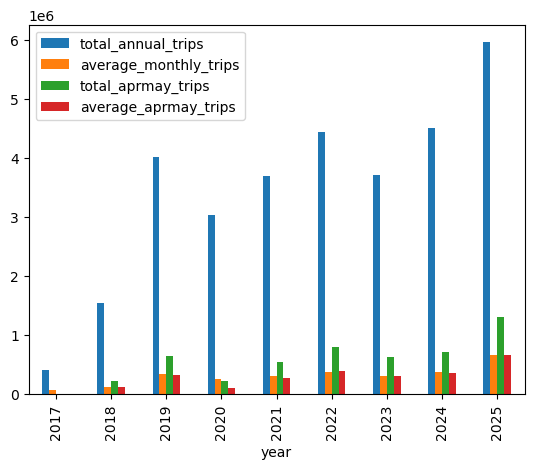

In [10]:
trips.plot.bar()

In [11]:
trips.to_csv(OUTDIR / OFILE)